# Mammal species survival analysis: a data-driven prior for species duration

**Purpose.** This notebook builds an empirical prior distribution for *mammalian
species duration* (time from origination to extinction), derived from real
fossil-occurrence data pulled from the Paleobiology Database (PBDB). It is a
companion piece to `human_population_bayesian_model_v5.ipynb` and the broader
question motivating this whole project thread: given that Homo sapiens does not
occupy a privileged position at the start or end of its own history, how might
we reason about how much longer the species is likely to persist (setting aside
sudden catastrophes)?

That question decomposes into several pieces (a Doomsday-argument-style
self-sampling calculation, a population-genetics speciation model, and a
background extinction-rate / species-duration model). This notebook builds one
input to the third piece: **what does the actual fossil record say about how
long mammal species typically last, and with what uncertainty?**

We deliberately do *not* commit to a single point estimate (e.g. "mammal
species last ~1-2 million years on average"). Instead we build two full
candidate prior distributions from the data -- a nonparametric Kaplan-Meier
empirical curve, and a parametric log-logistic fit -- so that later modeling
can carry the actual shape of this uncertainty forward, and so the choice of
distributional family can be revisited rather than baked in silently.

**Data source note.** We wanted to combine two sources -- the Paleobiology
Database (PBDB) and the NOW database (New and Old Worlds Database of Fossil
Mammals, which focuses specifically on terrestrial mammals) -- but a usable NOW
extract could not be obtained this round. This notebook proceeds on PBDB alone;
folding in NOW data is a natural extension once that data is available (see
Section 8).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from lifelines import KaplanMeierFitter, ExponentialFitter, WeibullFitter, LogNormalFitter, LogLogisticFitter

RNG_SEED = 20260828
rng = np.random.default_rng(RNG_SEED)

pd.set_option("display.max_columns", 20)
print("lifelines and scipy loaded OK")


lifelines and scipy loaded OK


## 1. Data source

`pbdb_data.csv` was downloaded directly from the Paleobiology Database's
`taxa/list` API endpoint, using:

```
https://paleobiodb.org/data1.2/taxa/list.csv?base_name=Mammalia&show=full&order=hierarchy
```

This endpoint returns, for every taxon in the queried group, PBDB's own
computed first- and last-appearance age bounds (`firstapp_max_ma`,
`firstapp_min_ma`, `lastapp_max_ma`, `lastapp_min_ma`) directly -- there is no
need to aggregate raw occurrence records ourselves. The file begins with a
16-line metadata preamble (data provider, license, the exact query used, record
counts) before the actual data table starts, which we skip on load.


In [2]:
RAW_PATH = "pbdb_data.csv"

with open(RAW_PATH) as f:
    preamble = [next(f) for _ in range(16)]
print("".join(preamble))

df_raw = pd.read_csv(RAW_PATH, skiprows=16, low_memory=False)
print(f"Raw taxa records: {len(df_raw):,}")
print(f"Columns: {len(df_raw.columns)}")


"Data Provider","The Paleobiology Database"
"Data Source","The Paleobiology Database"
"Data License","Creative Commons CC0"
"License URL","https://creativecommons.org/publicdomain/zero/1.0/"
"Documentation URL","http://paleobiodb.org/data1.2/taxa/list_doc.html"
"Data URL","http://paleobiodb.org/data1.2/taxa/list.csv?datainfo&rowcount&base_name=Mammalia&show=full&order=hierarchy"
"Access Time","Fri 2026-08-28 21:59:00 GMT"
"Title","PBDB Data Service"
"Parameters:"
"","base_name","Mammalia"
"","show","full"
"","order","hierarchy"
"Elapsed Time","0.945"
"Records Found","34129"
"Records Returned","34129"
"Records:"



Raw taxa records: 34,129
Columns: 52


## 2. Filtering to species, and deduplicating synonyms

The raw export includes every taxonomic rank PBDB has an opinion on (class,
order, family, genus, species, subspecies, etc.) -- we want species only. We
also require at least one fossil occurrence (`n_occs > 0`); taxa with zero
occurrences have no age data to compute a duration from (this affects ~4,400
of the ~20,500 nominal species records, and is *not* the resolution problem
described in Section 3 -- these are simply taxa with no fossils attributed to
them directly).

The export also contains multiple rows per *accepted* taxon when a species has
recognized synonyms -- each synonym gets its own row, but points to the same
`accepted_no` and (should) share the same computed age bounds. We deduplicate
down to one row per accepted taxon.


In [3]:
species = df_raw[(df_raw["accepted_rank"] == "species") & (df_raw["n_occs"] > 0)].copy()
print(f"Species-rank records with >=1 occurrence: {len(species):,}")

# Sanity check: do synonym rows pointing at the same accepted taxon agree on age bounds?
age_cols = ["firstapp_max_ma", "firstapp_min_ma", "lastapp_max_ma", "lastapp_min_ma"]
disagreement = species.groupby("accepted_no")[age_cols].nunique()
n_disagree = (disagreement > 1).any(axis=1).sum()
print(f"accepted_no groups with internally inconsistent age bounds: {n_disagree} "
      f"(out of {species['accepted_no'].nunique():,} unique accepted taxa)")

dedup = species.drop_duplicates(subset="accepted_no", keep="first").copy()
print(f"After deduplication to one row per accepted species: {len(dedup):,}")


Species-rank records with >=1 occurrence: 16,128
accepted_no groups with internally inconsistent age bounds: 4 (out of 12,556 unique accepted taxa)
After deduplication to one row per accepted species: 12,556


## 3. Computing duration -- and a real stratigraphic-resolution problem

PBDB reports first/last appearance as **bounded intervals**, not point
estimates: `firstapp_max_ma` and `firstapp_min_ma` bracket the geological
stage(s) in which the earliest known occurrence falls (similarly for last
appearance). This gives us three natural ways to define a species' fossil
duration:

- **`dur_max`** = `firstapp_max_ma - lastapp_min_ma` (the *widest* possible span
  consistent with the data)
- **`dur_min`** = `firstapp_min_ma - lastapp_max_ma` (the *narrowest* possible
  span; clipped at a small positive floor since it can be zero or, from
  interval-overlap artifacts, even slightly negative)
- **`dur_mid`** = the difference of the interval midpoints (a natural point
  estimate)

We compute all three and immediately hit exactly the reliability problem
flagged in our earlier literature review (Signor & Lipps 1982; the general
issue of stratigraphic resolution limiting fossil range estimates -- see
Section 9): **for most species, `dur_min` collapses to essentially zero.**
This is not evidence that most mammal species were short-lived -- it means
most fossil species are only datable to the resolution of one or two
geological stages, so PBDB's own uncertainty bounds cannot distinguish "first
appearance" from "last appearance" any more finely than that. We therefore use
`dur_max` -- the outer bound -- as our working duration measure throughout the
rest of this notebook. This is the more defensible choice given the floor
effect, but it is worth remembering that it is itself an upper bound on the
*resolvable* duration, and it may inherit some bias from uneven stratigraphic
stage lengths across geological time (older stages tend to be coarser/longer
than very recent ones -- see Section 8).


In [4]:
dedup["dur_max"] = dedup["firstapp_max_ma"] - dedup["lastapp_min_ma"]
dedup["dur_min"] = (dedup["firstapp_min_ma"] - dedup["lastapp_max_ma"]).clip(lower=0.0001)
dedup["dur_mid"] = (
    (dedup["firstapp_max_ma"] + dedup["firstapp_min_ma"]) / 2
    - (dedup["lastapp_max_ma"] + dedup["lastapp_min_ma"]) / 2
).clip(lower=0.0001)

print("Fraction of species at (or effectively at) the dur_min floor:",
      f"{(dedup['dur_min'] <= 0.0001).mean():.1%}")
print()
print("dur_max summary (Myr) -- our working duration measure:")
print(dedup["dur_max"].describe(percentiles=[.05, .25, .5, .75, .95]))


Fraction of species at (or effectively at) the dur_min floor: 86.7%

dur_max summary (Myr) -- our working duration measure:
count    12556.000000
mean         6.212319
std          5.036955
min          0.011700
5%           0.762300
25%          2.753000
50%          4.700000
75%          7.930000
95%         17.707000
max        118.820000
Name: dur_max, dtype: float64


## 4. Censoring: extant species are not "short-lived," they're incomplete

1,021 of these species are still alive today (`is_extant == "extant"`). Their
duration *so far* is not a completed observation -- it's a lower bound on
whatever their eventual total duration will turn out to be. Treating it as a
completed duration would bias the whole distribution toward shorter durations.
The statistically correct treatment is **right-censoring**: we keep these
species in the dataset, but flag that their "extinction event" has not (yet)
been observed, and let the survival-analysis machinery in Section 5 handle the
distinction properly (this is exactly what tools like the Kaplan-Meier
estimator were built for).

A further 87 species have unresolved extant/extinct status in this export and
are dropped, since we can't classify them as censored or complete.


In [5]:
data = dedup[dedup["is_extant"].isin(["extinct", "extant"])].copy()
data["event_observed"] = (data["is_extant"] == "extinct").astype(int)  # 1 = extinction observed, 0 = still alive
data["duration"] = data["dur_max"]

print(data["is_extant"].value_counts())
print()
print(f"Total usable species: {len(data):,}  "
      f"({(data['event_observed']==1).sum():,} extinct / {(data['event_observed']==0).sum():,} extant-censored)")

data.to_csv("mammal_species_durations_full.csv", index=False)


is_extant
extinct    11448
extant      1021
Name: count, dtype: int64

Total usable species: 12,469  (11,448 extinct / 1,021 extant-censored)


## 5. Survival analysis: nonparametric and parametric fits

We fit:
- **Kaplan-Meier** (Kaplan & Meier 1958) -- the standard nonparametric
  survival-curve estimator, correctly accounting for the right-censored extant
  species. This makes no distributional assumption at all; it is the most
  faithful representation of what the data actually show.
- Four parametric survival models fit by maximum likelihood, also properly
  accounting for censoring: **Exponential** (constant hazard -- this is the
  model implied by Van Valen's 1973 "Law of Extinction"), **Weibull**,
  **Log-Normal**, and **Log-Logistic**.

We compare the parametric fits by AIC (lower is better).


In [6]:
T = data["duration"].values
E = data["event_observed"].values

kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E, label="Kaplan-Meier (empirical)")

fitters = {
    "Exponential":  ExponentialFitter(),
    "Weibull":      WeibullFitter(),
    "LogNormal":    LogNormalFitter(),
    "LogLogistic":  LogLogisticFitter(),
}
aic_table = []
for name, f in fitters.items():
    f.fit(T, event_observed=E)
    aic_table.append(dict(model=name, AIC=f.AIC_, params=dict(f.summary["coef"])))

aic_df = pd.DataFrame(aic_table).sort_values("AIC").reset_index(drop=True)
print(aic_df.to_string())


         model           AIC                                                      params
0  LogLogistic  64341.543971  {'alpha_': 5.253356721208577, 'beta_': 2.2698597400438576}
1      Weibull  64528.299350  {'lambda_': 7.405532738113934, 'rho_': 1.4252164247364245}
2    LogNormal  65683.101723   {'mu_': 1.6237827480948064, 'sigma_': 0.8386853732316856}
3  Exponential  66720.124474                              {'lambda_': 6.779912569625332}


In [7]:
llf = fitters["LogLogistic"]
wf = fitters["Weibull"]
ef = fitters["Exponential"]

print("Log-logistic fit (best AIC):")
print(f"  alpha_ (scale) = {llf.alpha_:.4f}")
print(f"  beta_  (shape) = {llf.beta_:.4f}")
print()
print("Weibull fit, for comparison:")
print(f"  lambda_ (scale) = {wf.lambda_:.4f}")
print(f"  rho_    (shape) = {wf.rho_:.4f}  ({'increasing' if wf.rho_ > 1 else 'decreasing' if wf.rho_ < 1 else 'constant'} hazard with age)")
print()
print("Note: the Weibull shape parameter rho_ > 1 indicates the fitted hazard *increases*")
print("with species age, which runs counter to the constant-hazard assumption of Van Valen's")
print("Law of Extinction (the Exponential model). The Exponential model is in fact the worst-")
print("fitting of the four here by AIC. See Section 8 for caveats on how much weight to put")
print("on this specific finding given the dur_max measurement choice.")


Log-logistic fit (best AIC):
  alpha_ (scale) = 5.2534
  beta_  (shape) = 2.2699

Weibull fit, for comparison:
  lambda_ (scale) = 7.4055
  rho_    (shape) = 1.4252  (increasing hazard with age)

Note: the Weibull shape parameter rho_ > 1 indicates the fitted hazard *increases*
with species age, which runs counter to the constant-hazard assumption of Van Valen's
Law of Extinction (the Exponential model). The Exponential model is in fact the worst-
fitting of the four here by AIC. See Section 8 for caveats on how much weight to put
on this specific finding given the dur_max measurement choice.


## 6. Diagrams

**Figure 1** compares the empirical (Kaplan-Meier) survival curve against the
Weibull, Log-Logistic, and Exponential fits. **Figure 2** shows the
corresponding fitted hazard functions (instantaneous extinction risk as a
function of species age), with the Exponential's constant hazard shown as a
flat reference line.


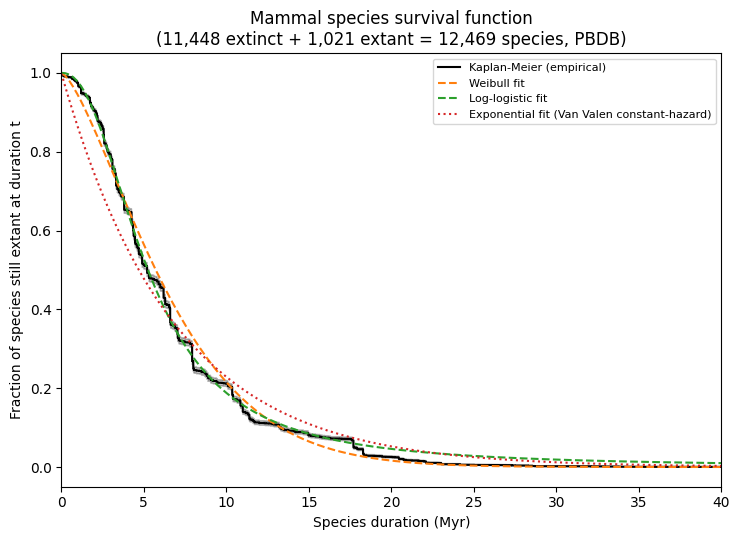

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
kmf.plot_survival_function(ax=ax, ci_show=True, color="black")
wf.plot_survival_function(ax=ax, ci_show=False, linestyle="--", label="Weibull fit")
llf.plot_survival_function(ax=ax, ci_show=False, linestyle="--", label="Log-logistic fit")
ef.plot_survival_function(ax=ax, ci_show=False, linestyle=":", label="Exponential fit (Van Valen constant-hazard)")
ax.set_xlabel("Species duration (Myr)")
ax.set_ylabel("Fraction of species still extant at duration t")
ax.set_title(f"Mammal species survival function\n"
             f"({(data['event_observed']==1).sum():,} extinct + {(data['event_observed']==0).sum():,} extant "
             f"= {len(data):,} species, PBDB)")
ax.set_xlim(0, 40)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig1_survival_function.png", dpi=150)
plt.show()


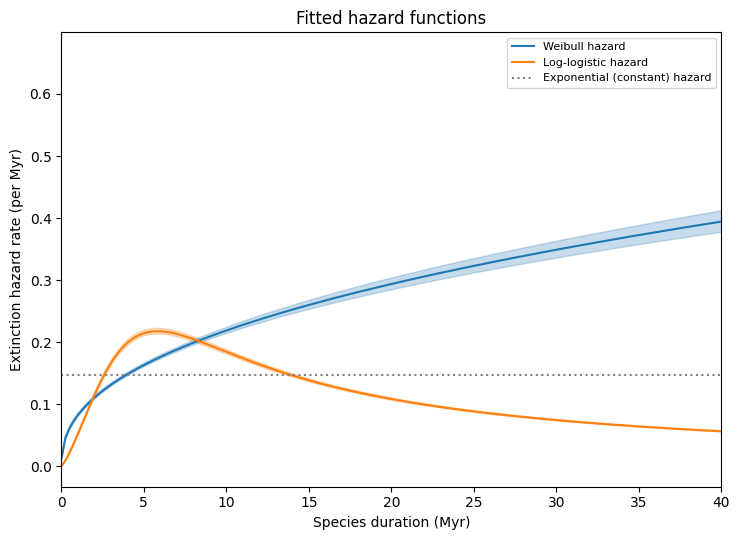

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
wf.plot_hazard(ax=ax, label="Weibull hazard")
llf.plot_hazard(ax=ax, label="Log-logistic hazard")
ax.axhline(1 / ef.lambda_, color="gray", linestyle=":", label="Exponential (constant) hazard")
ax.set_xlabel("Species duration (Myr)")
ax.set_ylabel("Extinction hazard rate (per Myr)")
ax.set_title("Fitted hazard functions")
ax.set_xlim(0, 40)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig2_hazard_function.png", dpi=150)
plt.show()


## 7. Two priors for later use

As agreed, we carry forward **two** candidate priors rather than committing to
one, so later modeling can compare sensitivity to this choice:

- **Prior A -- Kaplan-Meier empirical.** The full nonparametric survival curve,
  used directly as a sampling distribution via inverse-transform sampling on
  its (step-function) CDF. This makes no parametric assumption and is the most
  faithful representation of the data, at the cost of being an empirical table
  rather than a closed-form distribution.
- **Prior B -- Log-logistic parametric.** The best-AIC parametric fit from
  Section 5. Log-logistic is `scipy.stats.fisk` under a shape/scale
  reparameterization (`c = beta_`, `scale = alpha_`), which gives us a
  closed-form distribution that's easy to sample from and to reason about
  analytically (e.g. for use as a conjugate-ish prior family or for fast
  vectorized sampling inside a larger PyMC model).

Both are built below as simple Python samplers so they can be dropped into
later notebooks (e.g. as an input to a Doomsday-argument-style or survival-
based "time remaining" calculation for Homo sapiens).


In [10]:
# --- Prior A: Kaplan-Meier empirical sampler (inverse-transform on the step CDF) ---
sf = kmf.survival_function_.reset_index()
sf.columns = ["t", "S"]
sf["cdf"] = 1 - sf["S"]

# Keep only points where the CDF strictly increases, so interpolation is well-defined
keep = np.concatenate([[True], np.diff(sf["cdf"].values) > 0])
t_grid = sf["t"].values[keep]
cdf_grid = sf["cdf"].values[keep]
if cdf_grid[0] > 0:
    t_grid = np.concatenate([[0.0], t_grid])
    cdf_grid = np.concatenate([[0.0], cdf_grid])

def sample_km_prior(n, rng=rng):
    u = rng.uniform(0.0, cdf_grid[-1], size=n)
    return np.interp(u, cdf_grid, t_grid)

# --- Prior B: Log-logistic (Fisk) parametric sampler ---
loglogistic_dist = stats.fisk(c=llf.beta_, scale=llf.alpha_)

def sample_loglogistic_prior(n, rng=rng):
    return loglogistic_dist.rvs(size=n, random_state=rng)

km_draws = sample_km_prior(200_000)
ll_draws = sample_loglogistic_prior(200_000)

comparison = pd.DataFrame({
    "quantile": [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95],
    "KM_empirical (Myr)": np.quantile(km_draws, [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]),
    "LogLogistic (Myr)":  np.quantile(ll_draws, [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]),
})
print(comparison.to_string(index=False))


 quantile  KM_empirical (Myr)  LogLogistic (Myr)
     0.05            1.200000           1.438680
     0.10            2.073529           1.996203
     0.25            3.234323           3.235859
     0.50            5.200000           5.261592
     0.75            7.999277           8.547493
     0.90           13.300000          13.837516
     0.95           17.711942          19.241372


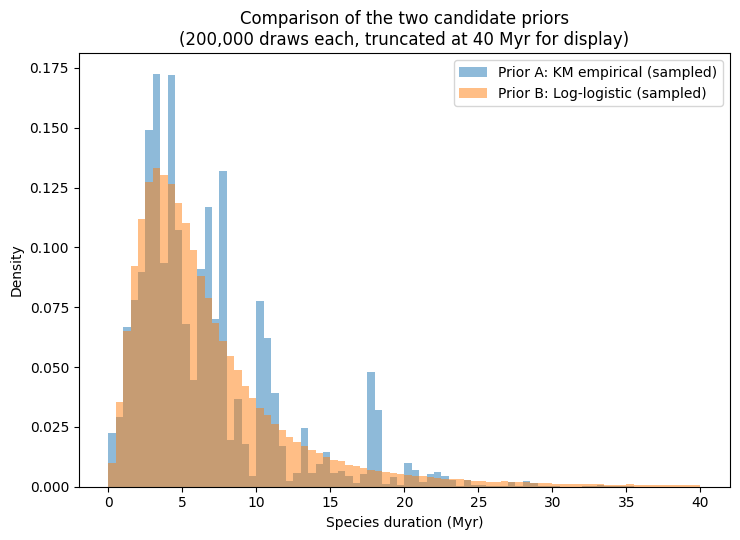

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
bins = np.linspace(0, 40, 81)
ax.hist(km_draws[km_draws < 40], bins=bins, density=True, alpha=0.5, label="Prior A: KM empirical (sampled)")
ax.hist(ll_draws[ll_draws < 40], bins=bins, density=True, alpha=0.5, label="Prior B: Log-logistic (sampled)")
ax.set_xlabel("Species duration (Myr)")
ax.set_ylabel("Density")
ax.set_title("Comparison of the two candidate priors\n(200,000 draws each, truncated at 40 Myr for display)")
ax.legend()
plt.tight_layout()
plt.savefig("fig3_prior_comparison.png", dpi=150)
plt.show()


## 8. Limitations and next steps

- **`dur_max` is an upper bound on a resolvable duration, not a true point
  estimate.** As shown in Section 3, the alternative (`dur_min`) is unusable
  for most species due to stratigraphic resolution limits. `dur_max` avoids
  that floor problem but may itself be inflated for species dated to long,
  coarse geological stages, and geological stages are not uniform in length
  across time (older stages tend to be longer). This could distort the
  survival curve's shape, and specifically could contribute to (or fully
  explain) the increasing-hazard signal found in Section 5 -- that finding
  should be treated as provisional pending a more careful sensitivity check
  (e.g. re-running this analysis with `dur_mid`, or an interval-censored
  survival model that uses the full `[dur_min, dur_max]` range per species
  rather than collapsing to one point).
- **PBDB's taxonomic and stratigraphic scope is uneven** across time periods,
  geography, and research effort, as discussed in the literature review this
  notebook follows on from (Raup 1979; the "Pull of the Recent" effect).
  No correction for uneven sampling effort (e.g. Alroy-style sampling
  standardization) has been applied here.
- **NOW database data was not available this round.** NOW focuses specifically
  on terrestrial mammals and would be a valuable cross-check, since PBDB's
  mammal coverage includes marine mammals and is not evenly sampled across
  all mammalian habitats. Folding in NOW data is the natural next step.
- **Species-concept issues** (lumping/splitting, as discussed for hominins
  specifically in our earlier review) apply here too, though less acutely
  given the much larger sample size smooths out any single taxonomic dispute.
- **This is genus/species-level, not hominin-specific.** Hominins are a tiny,
  taxonomically contested subset of this broader distribution; this notebook
  gives an outside-view mammalian base rate, not a hominin-specific estimate.


## 9. References and data sources

**Primary data**
- The Paleobiology Database (PBDB). Data downloaded via the `taxa/list` API
  endpoint: `https://paleobiodb.org/data1.2/taxa/list.csv?base_name=Mammalia&show=full&order=hierarchy`.
  Data license: CC0. API documentation: `http://paleobiodb.org/data1.2/taxa/list_doc.html`.
- Peters, S.E. & McClennen, M. (2016). "The Paleobiology Database application
  programming interface." *Paleobiology*, 42(1), 1-7.

**Survival-analysis methods**
- Kaplan, E.L. & Meier, P. (1958). "Nonparametric estimation from incomplete
  observations." *Journal of the American Statistical Association*, 53(282),
  457-481. [The Kaplan-Meier estimator used in Section 5.]
- Davidson-Pilon, C. (2019). "lifelines: survival analysis in Python."
  *Journal of Open Source Software*, 4(40), 1317. [The `lifelines` package
  used throughout this notebook for censored survival-model fitting.]
- Klein, J.P. & Moeschberger, M.L. (2003). *Survival Analysis: Techniques for
  Censored and Truncated Data*, 2nd ed. Springer. [General reference for the
  parametric survival models (Exponential, Weibull, Log-Normal, Log-Logistic)
  and censoring theory used here.]

**Species-duration / macroevolutionary background (carried over from the prior
literature-review discussion in this project)**
- Van Valen, L. (1973). "A new evolutionary law." *Evolutionary Theory*, 1,
  1-30. [Origin of the constant-hazard "Law of Extinction," modeled here as
  the Exponential survival fit.]
- Prothero, D.R. (2014). "Species longevity in North American fossil
  mammals." *Integrative Zoology*, 9(4), 383-393.
- Signor, P.W. & Lipps, J.H. (1982). "Sampling bias, gradual extinction
  patterns, and catastrophes in the fossil record." *Geological Society of
  America Special Paper*, 190, 291-296. [The stratigraphic-resolution issue
  encountered directly in Section 3.]
- Raup, D.M. (1979). "Biases in the fossil record of species and genera."
  *Bulletin of the Carnegie Museum of Natural History*, 13, 85-91.
  [The "Pull of the Recent" and related sampling-bias issues, noted in
  Section 8.]
- Foote, M. & Raup, D.M. (1996). "Fossil preservation and the stratigraphic
  ranges of taxa." *Paleobiology*, 22(2), 121-140. [Statistical methods for
  correcting fossil-record incompleteness; relevant to the interval-censored
  refinement suggested in Section 8.]
- Marshall, C.R. (1990). "Confidence intervals on stratigraphic ranges."
  *Paleobiology*, 16(1), 1-10.
- Strauss, D. & Sadler, P.M. (1989). "Classical confidence intervals and
  Bayesian probability estimates for ends of local taxon ranges."
  *Mathematical Geology*, 21, 411-427.
